# Multimodal Travel Guide — Text + Image

![Workshop flow — you are here: Tool Calling & Multimodal AI](../assets/notebook_flow_diagram.png)

You are building a **travel guide agent** for a data scientist flying from one African city to another for a workshop.

### What does *multimodal* mean here?

One workflow, **two output types**:

| Modality | What creates it | You see it as |
|----------|-----------------|---------------|
| **Text** | Tools + LLM | Grounded travel brief |
| **Image** | Python code | Travel poster |

### How this notebook is organised (fast path)

| Step | What happens | Typical wait |
|------|----------------|--------------|
| 1–2 | Setup + trip details | seconds |
| 3 | Tools fetch real facts | ~5 s |
| 4 | LLM writes the **text** brief | ~20–40 s *(only slow step)* |
| 5 | Code builds the **image** poster | ~1 s |
| 6 | See both modalities together in the notebook | instant |
| 7 | Gradio preview — **opens instantly** with what you built | instant |

> **Teaching idea:** do the heavy work once in the notebook. Gradio is the exhibition layer — not a second 40-second wait.


## Step 1: Setup

Run both cells below, then continue in order.

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")


True

In [10]:
from src.llm_gateway import check_available_providers

SELECTED_PROVIDER = "auto"
WORKSHOP_MAX_TOKENS = 500  # shorter brief = faster LLM in class

check_available_providers()


{'openai': False,
 'anthropic': False,
 'gemini': False,
 'mistral': False,
 'cohere': False,
 'deepseek': False,
 'groq': False,
 'openrouter': False,
 'ollama': True}

## Step 2: Choose your trip

Defaults: **Kigali → Accra**. Edit here if you like, then re-run from Step 3.

In [11]:
base_city = "Kigali"
base_country = "Rwanda"
destination_city = "Accra"
destination_country = "Ghana"
base_currency = "RWF"
destination_currency = "GHS"
traveller_profile = "data scientist attending an AI workshop"


## Step 3: Modality 0 — gather facts with tools

**Rule:** the LLM must not invent weather or exchange rates. Python calls tools first.

This step is quick (~5 seconds). We store tables for later steps.

In [12]:
import time
from src.travel_tools import gather_travel_tool_results
from src.output_formatting import format_tool_evidence_dataframe, format_places_dataframe

t0 = time.time()
evidence = gather_travel_tool_results(
    base_city,
    base_country,
    destination_city,
    destination_country,
    base_currency,
    destination_currency,
    amount=100,
)
tool_df = format_tool_evidence_dataframe(evidence)
places_df = format_places_dataframe(evidence["places"])
print(f"Tools finished in {time.time() - t0:.1f}s")

tool_df


Tools finished in 6.4s


,Source,Fact,Value
0,Weather,Summary,Overcast
1,Weather,Temperature,25.9°C
2,Weather,Rain chance,100%
3,Weather,Wind,15.9 km/h
4,Distance,Straight-line km,3462.3
5,Distance,Note,"Approximate straight-line distance, not flight..."
6,Exchange,Rate,1 RWF = 0.00778 GHS
7,Exchange,Example,100 RWF → 0.778 GHS
8,Exchange,Date,2026-06-29


In [13]:
places_df

,Place,Why visit,Data angle
0,Kwame Nkrumah Memorial Park,Learn about Ghana's independence history.,Connect civic history with public data and nat...
1,Labadi Beach area,Experience local culture and leisure spaces.,Tourism analytics and coastal urban planning u...
2,Osu / Oxford Street area,"Good for food, shopping, and people-watching.",Retail activity and urban mobility patterns in...


## Step 4: Modality 1 — grounded **text** brief (LLM)

We pass tool evidence into the prompt so the model **explains** facts instead of guessing them.

This is the slow step (~20–40 s with Ollama). You only wait here once.

In [14]:
import time
from src.llm_gateway import run_llm
from src.prompt_templates import build_travel_brief_prompt
from src.output_formatting import format_travel_brief_markdown, show_llm_output

prompt = build_travel_brief_prompt(
    base_city,
    base_country,
    destination_city,
    destination_country,
    traveller_profile,
    evidence["weather"],
    evidence["distance"],
    evidence["exchange"],
    evidence["places"],
)

t0 = time.time()
travel_reply = run_llm(
    prompt,
    provider=SELECTED_PROVIDER,
    temperature=0.3,
    max_tokens=WORKSHOP_MAX_TOKENS,
)
print(f"LLM finished in {time.time() - t0:.1f}s")

brief_md = format_travel_brief_markdown(
    travel_reply,
    base_city,
    base_country,
    destination_city,
    destination_country,
)
show_llm_output(travel_reply, title=f"{base_city} → {destination_city}")


LLM finished in 16.0s


## Kigali → Accra

Short briefing:
-------------------

A data scientist is traveling to Accra, Ghana for an AI workshop. They will be leaving from Kigali, Rwanda.

Weather summary:
-----------------------

The weather in Accra on the date of the AI workshop is overcast with a 100% precipitation probability. The temperature is expected to be 25.9 °C, and the wind speed will be around 15.9 km/h.

Distance note:
---------------------

The straight-line distance from Kigali to Accra is approximately 3462.3 km.

Exchange rate note:
--------------------------

The exchange rate between RWF and GHS on the date of the AI workshop is 1 RWF = 0.778 GHS. A sample conversion for an amount of 100 RWF will be 0.778 GHS.

Top 3 places:
---------------------

* Kwame Nkrumah Memorial Park: Landmark dedicated to Ghana's first president, which could serve as a data-science study case for historical preservation and tourism impact analysis.
* Labadi Beach area: Popular coastal area near the city centre, which can be studied for its beach management, local economy, and environmental sustainability.
* Osu / Oxford Street area: Busy commercial and social district that could serve as a case study for urban planning, traffic management, and small business operations.

Practical caution:
-------------------------

It is important to note the current COVID-19 guidelines and restrictions in both Rwanda and Ghana when traveling. Please make sure to follow all necessary health and safety protocols during your trip.

One-sentence summary:
-----------------------------

The data scientist will be traveling from Kigali, Rwanda to Accra, Ghana for an AI workshop, experiencing overcast weather with a 100% precipitation probability on the date of the workshop, and visiting landmarks like the Kwame Nkrumah Memorial Park and Osu / Oxford Street area while also being aware of the current COVID-19 guidelines and restrictions in both countries.

## Step 5: Modality 2 — **image** poster

`fast=True` skips slow cloud image APIs and builds a poster with Pillow in about a second.

In [15]:
import time
import importlib
import src.image_generation as image_generation

# Reload picks up the latest src code without a kernel restart.
importlib.reload(image_generation)
from src.image_generation import generate_travel_poster

t0 = time.time()
poster = generate_travel_poster(
    destination_city,
    destination_country,
    evidence["places"],
    fast=True,
)
print(f"Poster finished in {time.time() - t0:.1f}s ({poster['provider']})")
poster


Poster finished in 0.1s (pil_fallback)


{'status': 'success',
 'provider': 'pil_fallback',
 'path': '/Users/jeremiah/Documents/DSA/Practical Sessions/generative-ai-workshop/data/outputs/generated_images/travel_poster_accra.png'}

## Step 6: See multimodal output in the notebook

Same trip — **text** and **image** — side by side. This is the idea you will ship in Gradio next.

## Kigali, Rwanda → Accra, Ghana

_Facts below come from live tools. Verify before real travel._

Short briefing:
-------------------

A data scientist is traveling to Accra, Ghana for an AI workshop. They will be leaving from Kigali, Rwanda.

Weather summary:
-----------------------

The weather in Accra on the date of the AI workshop is overcast with a 100% precipitation probability. The temperature is expected to be 25.9 °C, and the wind speed will be around 15.9 km/h.

Distance note:
---------------------

The straight-line distance from Kigali to Accra is approximately 3462.3 km.

Exchange rate note:
--------------------------

The exchange rate between RWF and GHS on the date of the AI workshop is 1 RWF = 0.778 GHS. A sample conversion for an amount of 100 RWF will be 0.778 GHS.

Top 3 places:
---------------------

* Kwame Nkrumah Memorial Park: Landmark dedicated to Ghana's first president, which could serve as a data-science study case for historical preservation and tourism impact analysis.
* Labadi Beach area: Popular coastal area near the city centre, which can be studied for its beach management, local economy, and environmental sustainability.
* Osu / Oxford Street area: Busy commercial and social district that could serve as a case study for urban planning, traffic management, and small business operations.

Practical caution:
-------------------------

It is important to note the current COVID-19 guidelines and restrictions in both Rwanda and Ghana when traveling. Please make sure to follow all necessary health and safety protocols during your trip.

One-sentence summary:
-----------------------------

The data scientist will be traveling from Kigali, Rwanda to Accra, Ghana for an AI workshop, experiencing overcast weather with a 100% precipitation probability on the date of the workshop, and visiting landmarks like the Kwame Nkrumah Memorial Park and Osu / Oxford Street area while also being aware of the current COVID-19 guidelines and restrictions in both countries.

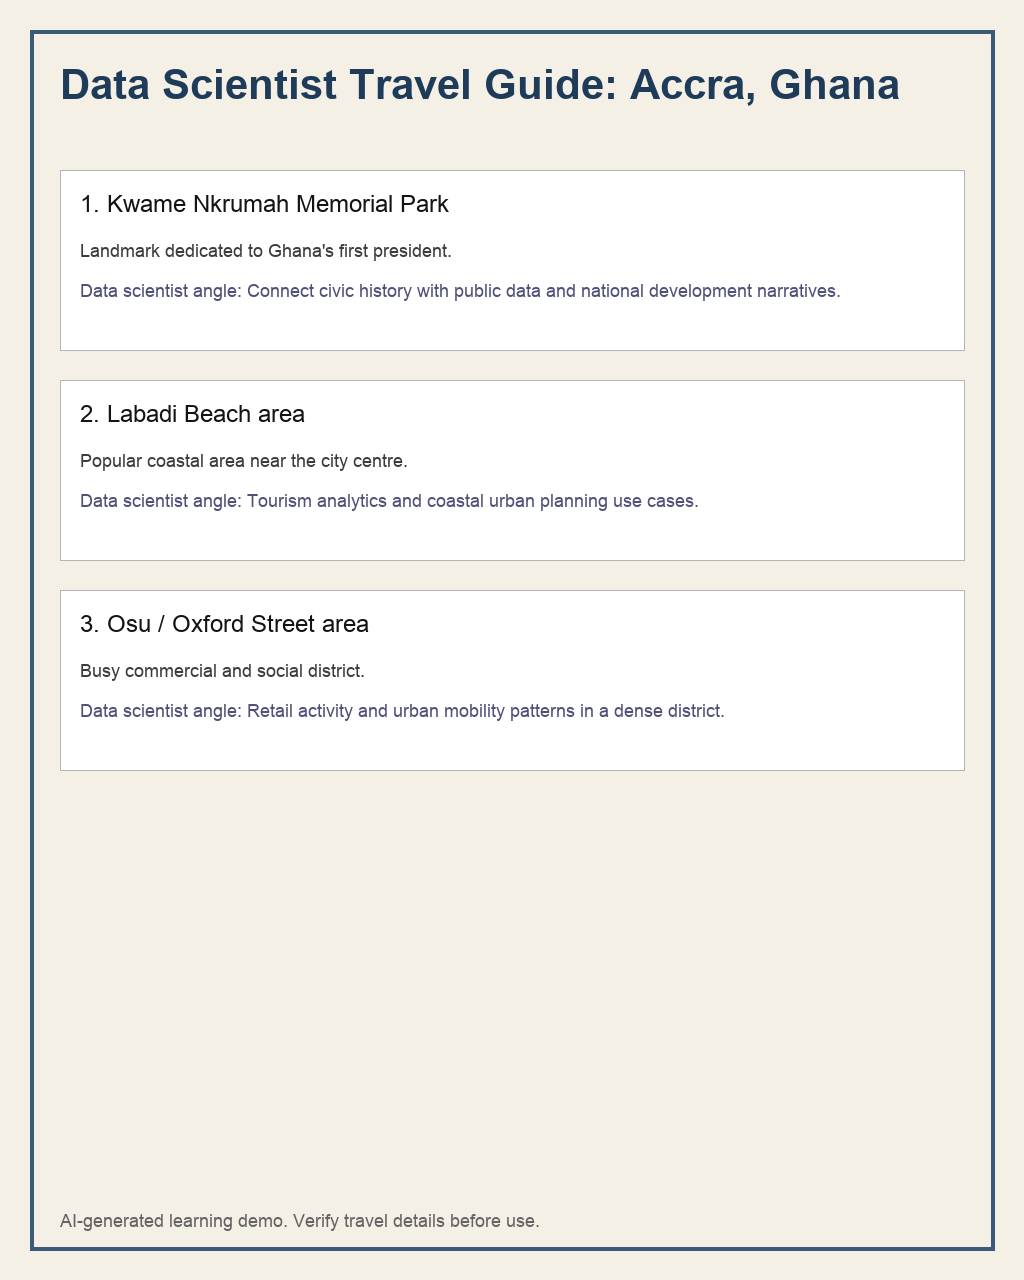

In [16]:
import importlib
import src.output_formatting as output_formatting

importlib.reload(output_formatting)
from src.output_formatting import show_multimodal_travel_guide

show_multimodal_travel_guide(
    brief_md,
    poster["path"],
    route_label=f"{base_city}, {base_country} → {destination_city}, {destination_country}",
)


## Step 7: Gradio preview (instant)

We **pack** what you already built and open a UI that loads immediately — no second LLM call.

1. Run the cell below (launches in a few seconds).
2. The brief, tables, and poster should already be visible.
3. Optional: expand *Generate a different trip* only if you want the slow full pipeline.

**Tip:** run this cell once per session. Use **Kernel → Restart** to relaunch after editing Steps 2–6.

In [17]:
from src.tour_session import pack_tour_session
from src.gradio_apps import build_tour_guide_preview_app

session = pack_tour_session(
    base_city,
    base_country,
    destination_city,
    destination_country,
    base_currency,
    destination_currency,
    traveller_profile,
    brief_md=brief_md,
    tool_df=tool_df,
    places_df=places_df,
    poster_path=poster["path"],
)

tour = build_tour_guide_preview_app(session)
tour.launch(share=False, show_error=True)


/Users/jeremiah/miniconda3/envs/llm/lib/python3.13/site-packages/gradio/routes.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


## Reflection

1. What should the model **not** guess?
2. Why call external tools **before** the LLM?
3. What are the two modalities in *your* app?
4. Why is the Gradio step fast if you ran Steps 3–6 first?
5. What could go wrong if weather or rates were hallucinated?

**Verify before travel:** this is a teaching demo, not live travel advice.
